============================================================\
**Notebook 01** : Data Preprocessing & Feature Engineering\
**Output** : processed_features.csv, X_train/test, y_train/test, scaler.pkl\
============================================================\

In [1]:
import os
import warnings

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [2]:

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')

# setting plot sizes globally
plt.rcParams['figure.figsize'] = (10, 4)
plt.rcParams['axes.titlesize'] = 13

print('Imports and Configs successful')

Imports and Configs successful


In [3]:
print(os.listdir('../data/'))

['online-retail.xlsx']


---
### 1. Load Data

In [4]:
# Load the dataset — adjust path if needed
df = pd.read_excel('../data/online-retail.xlsx', dtype={'CustomerID': str})  # make customer id string

print(f'Shape: {df.shape}')
print(f'Rows: {df.shape[0]:,}  |  Columns: {df.shape[1]}')
df.head(10)

Shape: (541909, 8)
Rows: 541,909  |  Columns: 8


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,2010-12-01 08:26:00,7.65,17850,United Kingdom
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,2010-12-01 08:26:00,4.25,17850,United Kingdom
7,536366,22633,HAND WARMER UNION JACK,6,2010-12-01 08:28:00,1.85,17850,United Kingdom
8,536366,22632,HAND WARMER RED POLKA DOT,6,2010-12-01 08:28:00,1.85,17850,United Kingdom
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,2010-12-01 08:34:00,1.69,13047,United Kingdom


---
### 2. Basic Overview

In [5]:
# Column data types
print('=== Data Types ===')
print(df.dtypes)
print()
print('=== Basic Stats ===')
df.describe()

=== Data Types ===
InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[us]
UnitPrice             float64
CustomerID                str
Country                   str
dtype: object

=== Basic Stats ===


,Quantity,InvoiceDate,UnitPrice
count,541909.000000,541909,541909.000000
mean,9.552250,2011-07-04 13:34:57.156386,4.611114
min,-80995.000000,2010-12-01 08:26:00,-11062.060000
25%,1.000000,2011-03-28 11:34:00,1.250000
50%,3.000000,2011-07-19 17:17:00,2.080000
75%,10.000000,2011-10-19 11:27:00,4.130000
max,80995.000000,2011-12-09 12:50:00,38970.000000
std,218.081158,NaN,96.759853


In [6]:
print('=== Unique Value Counts ===')
for col in df.columns:
    print(f'{col:15s}: {df[col].nunique():>7,} unique values')

=== Unique Value Counts ===
InvoiceNo      :  25,900 unique values
StockCode      :   4,070 unique values
Description    :   4,223 unique values
Quantity       :     722 unique values
InvoiceDate    :  23,260 unique values
UnitPrice      :   1,630 unique values
CustomerID     :   4,372 unique values
Country        :      38 unique values


The dataset has 4,372 unique customers, which is very well need for the future prediction

---
### 3. Missing Values

In [7]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).sort_values('Missing Count', ascending=False)

print(missing_df)

             Missing Count  Missing %
CustomerID          135080      24.93
Description           1454       0.27
StockCode                0       0.00
InvoiceNo                0       0.00
Quantity                 0       0.00
InvoiceDate              0       0.00
UnitPrice                0       0.00
Country                  0       0.00


CustomerID has 135,080 missing values (24.93%), the most critical issue. Since the model predicts repurchase per customer, rows without a CustomerID cannot be tracked and must be dropped. NEED TO DROP THE ROWS WITH MISSING VALUES IN THE PREPROCESSING STEP.

---
### 4. EDA - Distributions & Patterns

Normal invoices   : 532,621
Cancellations     : 9,288 (1.7%)


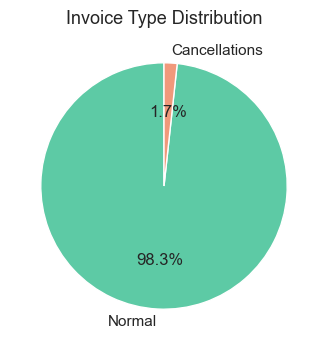

In [8]:
# Cancellations (InvoiceNo starting with 'C')
cancellations = df[df['InvoiceNo'].astype(str).str.startswith('C')]
normal = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

print(f'Normal invoices   : {len(normal):,}')
print(f'Cancellations     : {len(cancellations):,} ({len(cancellations) / len(df) * 100:.1f}%)')

labels = ['Normal', 'Cancellations']
sizes = [len(normal), len(cancellations)]
colors = ['#5DCAA5', '#F0997B']
plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
plt.title('Invoice Type Distribution')
plt.savefig('../outputs/invoice_type_pie.png', bbox_inches='tight')
plt.show()

These represent refunds, not real purchases, and must be removed to avoid misleading the repurchase prediction model.

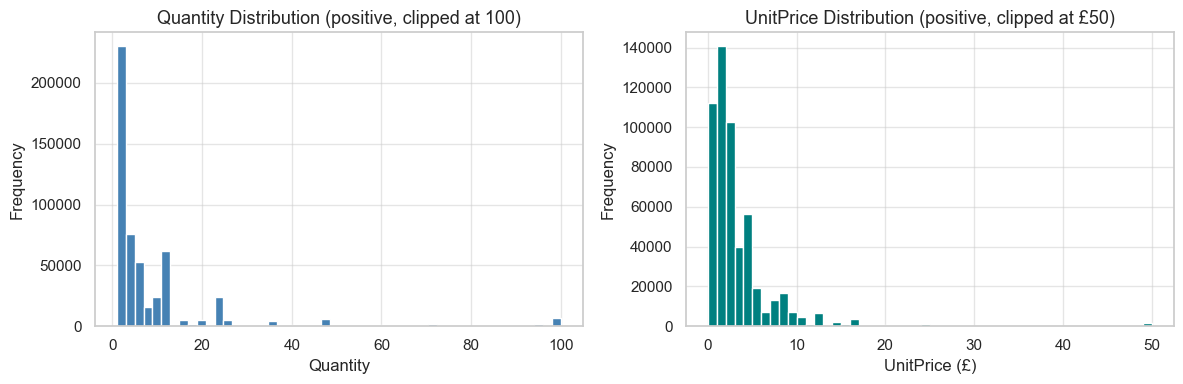

In [9]:
# Quantity and UnitPrice distributions (before cleaning)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Clip for readability
df[df['Quantity'] > 0]['Quantity'].clip(upper=100).plot(
    kind='hist', bins=50, ax=axes[0], color='steelblue', edgecolor='white'
)
axes[0].set_title('Quantity Distribution (positive, clipped at 100)')
axes[0].set_xlabel('Quantity')

df[df['UnitPrice'] > 0]['UnitPrice'].clip(upper=50).plot(
    kind='hist', bins=50, ax=axes[1], color='teal', edgecolor='white'
)
axes[1].set_title('UnitPrice Distribution (positive, clipped at £50)')
axes[1].set_xlabel('UnitPrice (£)')

plt.tight_layout()
plt.savefig('../outputs/quantity_unitprice_hist.png', bbox_inches='tight')
plt.show()

Both distributions are heavily right-skewed. Most orders contain 1–10 items and cost under £10, showing typical small retail purchases. A few large bulk orders create long tails and may be removed or capped during feature engineering since they are not considered normal purchasing behavior.


=== Orders per Customer ===
count    4339.000000
mean        4.271952
std         7.705493
min         1.000000
25%         1.000000
50%         2.000000
75%         5.000000
max       210.000000
Name: InvoiceNo, dtype: float64

Customers with only 1 order : 1,494 (34.4%)
Customers with 2+ orders   : 2,845 (65.6%)


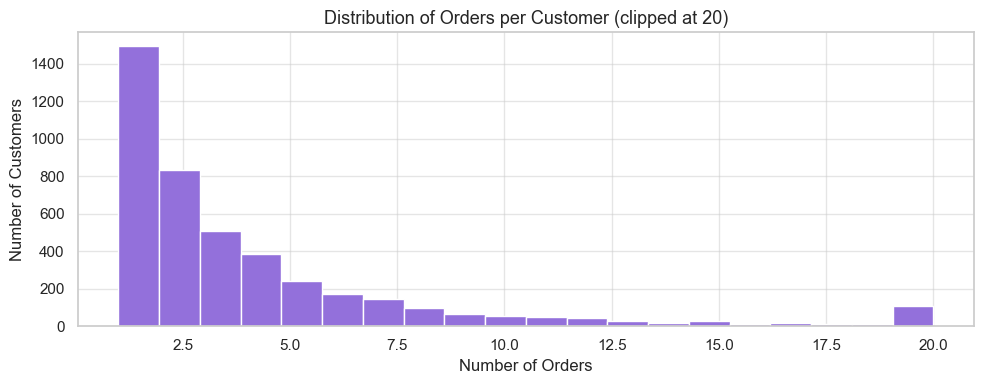

In [10]:
# Distribution of orders per customer
orders_per_customer = (
    df.dropna(subset=['CustomerID'])
    [~df['InvoiceNo'].astype(str).str.startswith('C')]
    .groupby('CustomerID')['InvoiceNo']
    .nunique()
)

print('=== Orders per Customer ===')
print(orders_per_customer.describe())
print(f'\nCustomers with only 1 order : {(orders_per_customer == 1).sum():,} ({(orders_per_customer == 1).mean() * 100:.1f}%)')
print(f'Customers with 2+ orders   : {(orders_per_customer >= 2).sum():,} ({(orders_per_customer >= 2).mean() * 100:.1f}%)')

orders_per_customer.clip(upper=20).plot(
    kind='hist', bins=20, color='mediumpurple', edgecolor='white'
)
plt.title('Distribution of Orders per Customer (clipped at 20)')
plt.xlabel('Number of Orders')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.savefig('../outputs/orders_per_customer_hist.png', bbox_inches='tight')
plt.show()

The distribution is heavily right-skewed, with most customers placing only 1–2 orders. This creates class imbalance, where most customers belong to class 0 (no repurchase within 90 days).


---
### 6. EDA - Sales Trends

In [11]:
# Parse dates for trend analysis
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['Year'] = df['InvoiceDate'].dt.year
df['Month'] = df['InvoiceDate'].dt.month
df['DayOfWeek'] = df['InvoiceDate'].dt.day_name()
df['Hour'] = df['InvoiceDate'].dt.hour

print('Date range:', df['InvoiceDate'].min(), 'to', df['InvoiceDate'].max())

Date range: 2010-12-01 08:26:00 to 2011-12-09 12:50:00


---
### 7. Preprocessing - Clean the Data

In [12]:
# 1. Drop rows with no CustomerID (can't track customers)
df = df.dropna(subset=['CustomerID'])

In [13]:
# 2. Remove cancelled orders (InvoiceNo starts with 'C')
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

In [14]:
# 3. Remove negative/zero quantities and prices
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]

In [15]:
# 4. Convert CustomerID to string (it's treated as a label, not a number)
df['CustomerID'] = df['CustomerID'].astype(str)

In [16]:
# 5. Parse InvoiceDate
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [17]:
# 6. Create TotalPrice column
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

In [18]:
print(f"Clean dataset shape: {df.shape}")
print(f"Unique customers: {df['CustomerID'].nunique()}")
print(f"Date range: {df['InvoiceDate'].min()} to {df['InvoiceDate'].max()}")

Clean dataset shape: (397884, 13)
Unique customers: 4338
Date range: 2010-12-01 08:26:00 to 2011-12-09 12:50:00


---
### 8. Feature Engineering

In [19]:
# Temporal split: features from first 9 months, label from last 3
feature_end = pd.Timestamp('2011-09-30')
label_start = pd.Timestamp('2011-10-01')

In [20]:
df_feat = df[df['InvoiceDate'] <= feature_end]
df_label = df[df['InvoiceDate'] >= label_start]

In [21]:
# Target: did this customer purchase in the label window?
returning_customers = set(df_label['CustomerID'].unique())

In [22]:
# RFM : Recency, Frequency, Monetary (total of the transactions per customer)
rfm = df_feat.groupby('CustomerID').agg(
    Recency=('InvoiceDate', lambda x: (feature_end - x.max()).days),
    Frequency=('InvoiceNo', 'nunique'),
    Monetary=('TotalPrice', 'sum')
).reset_index()

In [23]:
# Average order value
avg_order = (
    df_feat.groupby(['CustomerID', 'InvoiceNo'])['TotalPrice']
    .sum()
    .reset_index()
    .groupby('CustomerID')['TotalPrice']
    .mean()
    .reset_index(name='AvgOrderValue')
)

In [24]:
# Unique products purchased
unique_prods = (
    df_feat.groupby('CustomerID')['StockCode']
    .nunique()
    .reset_index(name='UniqueProducts')
)

In [25]:
# Purchase span in days
span = df_feat.groupby('CustomerID')['InvoiceDate'].agg(['min', 'max']).reset_index()
span.columns = ['CustomerID', 'FirstPurchase', 'LastPurchase']
span['PurchaseSpanDays'] = (span['LastPurchase'] - span['FirstPurchase']).dt.days

print(span)

     CustomerID       FirstPurchase        LastPurchase  PurchaseSpanDays
0         12346 2011-01-18 10:01:00 2011-01-18 10:01:00                 0
1         12347 2010-12-07 14:57:00 2011-08-02 08:48:00               237
2         12348 2010-12-16 19:09:00 2011-09-25 13:13:00               282
3         12350 2011-02-02 16:01:00 2011-02-02 16:01:00                 0
4         12352 2011-02-16 12:33:00 2011-09-28 14:58:00               224
...         ...                 ...                 ...               ...
3599      18280 2011-03-07 09:52:00 2011-03-07 09:52:00                 0
3600      18281 2011-06-12 10:53:00 2011-06-12 10:53:00                 0
3601      18282 2011-08-05 13:35:00 2011-08-05 13:35:00                 0
3602      18283 2011-01-06 14:14:00 2011-09-05 12:35:00               241
3603      18287 2011-05-22 10:39:00 2011-05-22 10:39:00                 0

[3604 rows x 4 columns]


In [26]:
# Merge all features
features = (rfm
            .merge(avg_order, on='CustomerID')
            .merge(unique_prods, on='CustomerID')
            .merge(span[['CustomerID', 'PurchaseSpanDays']], on='CustomerID')
            )

# Add target label
features['WillReturn'] = features['CustomerID'].isin(returning_customers).astype(int)

print(f"\nFeature matrix shape: {features.shape}")
print(f"Class balance:\n{features['WillReturn'].value_counts(normalize=True).round(3)}")
print(f"\nSample:\n{features.head()}")


Feature matrix shape: (3604, 8)
Class balance:
WillReturn
1    0.509
0    0.491
Name: proportion, dtype: float64

Sample:
  CustomerID  Recency  Frequency  Monetary  AvgOrderValue  UniqueProducts  \
0      12346      254          1  77183.60   77183.600000               1   
1      12347       58          5   2790.86     558.172000              82   
2      12348        4          4   1797.24     449.310000              22   
3      12350      239          1    334.40     334.400000              17   
4      12352        1          7   2194.31     313.472857              47   

   PurchaseSpanDays  WillReturn  
0                 0           0  
1               237           1  
2               282           0  
3                 0           0  
4               224           1  


In [27]:
# Save full feature table (useful for inspection/report)
features.to_csv('../outputs/csv/processed_features.csv', index=False)
print("Saved: processed_features.csv")

Saved: processed_features.csv


**Train/Test split**\
**Split ONCE here. Both model notebooks will load these**


In [28]:
from sklearn.model_selection import train_test_split

FEATURE_COLS = [
    'Recency', 'Frequency', 'Monetary',
    'AvgOrderValue', 'UniqueProducts', 'PurchaseSpanDays'
]

X = features[FEATURE_COLS]
y = features['WillReturn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # preserve class ratio in both splits
)

print(f"\nX_train: {X_train.shape}  |  X_test: {X_test.shape}")
print(f"y_train positives: {y_train.mean():.2%}  |  y_test positives: {y_test.mean():.2%}")



X_train: (2883, 6)  |  X_test: (721, 6)
y_train positives: 50.88%  |  y_test positives: 50.90%


In [29]:
# Save raw splits (before scaling) — RF doesn't need scaling
X_train.to_csv('../outputs/csv/X_train.csv', index=False)
X_test.to_csv('../outputs/csv/X_test.csv', index=False)
y_train.to_csv('../outputs/csv/y_train.csv', index=False)
y_test.to_csv('../outputs/csv/y_test.csv', index=False)
print("Saved: X_train, X_test, y_train, y_test")

Saved: X_train, X_test, y_train, y_test


**FIT & SAVE SCALER**\
**Fit scaler on TRAINING data only (never on test — data leakage rule)**

In [30]:
from sklearn.preprocessing import StandardScaler
import pickle

scaler = StandardScaler()
scaler.fit(X_train)  # fit only, don't transform here

with open('../outputs/models/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print("Saved: scaler.pkl")

Saved: scaler.pkl
